# 04 — Figures

Publication-quality figures:
1. World map of concentration index
2. Concentration curves — selected countries / all countries
3. CI vs mean productivity loss scatter
4. Regional summaries

**Prerequisite:** run notebook 03 to generate results CSVs.

In [32]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import yaml

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

with open(ROOT / 'config' / 'config.yaml') as f:
    config = yaml.safe_load(f)

DATA    = ROOT / 'data'
RESULTS = ROOT / 'results'

# --- Choose dataset and epoch to visualise ---
# Options: 'wbgt' | 'wbgt_baseline' | 'wbgt_future_2030_ssp245' | 'wbgt_future_2030_ssp585'
#          'wbgt_future_2050_ssp245' | 'wbgt_future_2050_ssp585'
DATASET = 'wbgt'

_cfg_key    = 'wbgt_future' if DATASET.startswith('wbgt_future') else DATASET
EPOCH_START = config[_cfg_key]['start_year']
EPOCH_END   = config[_cfg_key]['end_year']
# ---------------------------------------------

ci_file     = RESULTS / f'inequality_results_{DATASET}_{EPOCH_START}_{EPOCH_END}.csv'
curves_file = RESULTS / f'concentration_curves_{DATASET}_{EPOCH_START}_{EPOCH_END}.csv'

if not ci_file.exists():
    raise FileNotFoundError(
        f'{ci_file.name} not found. Run notebook 03 with DATASET = {DATASET!r} first.'
    )

ci_df     = pd.read_csv(ci_file)
curves_df = pd.read_csv(curves_file)

print(f'Dataset:   {DATASET}')
print(f'Epoch:     {EPOCH_START}–{EPOCH_END}')
print(f'Countries: {len(ci_df)}')
ci_df.head()

Dataset:   wbgt
Epoch:     1980–2025
Countries: 92


,iso3,epoch_start,epoch_end,CI,mean_productivity_loss,total_population,rwi_coverage,n_cells
0,AGO,1980,2025,0.422165,0.012953,34230328.0,0.893233,169207
1,ALB,1980,2025,0.011505,0.004227,2653648.0,0.958208,16227
2,ARG,1980,2025,-0.100360,0.011137,43348112.0,0.950375,185787
3,ARM,1980,2025,-0.187404,0.000116,2882809.5,0.972516,8794
4,BDI,1980,2025,0.257562,0.000079,13991450.0,0.983268,27193


## Figure 1 — World map of Concentration Index

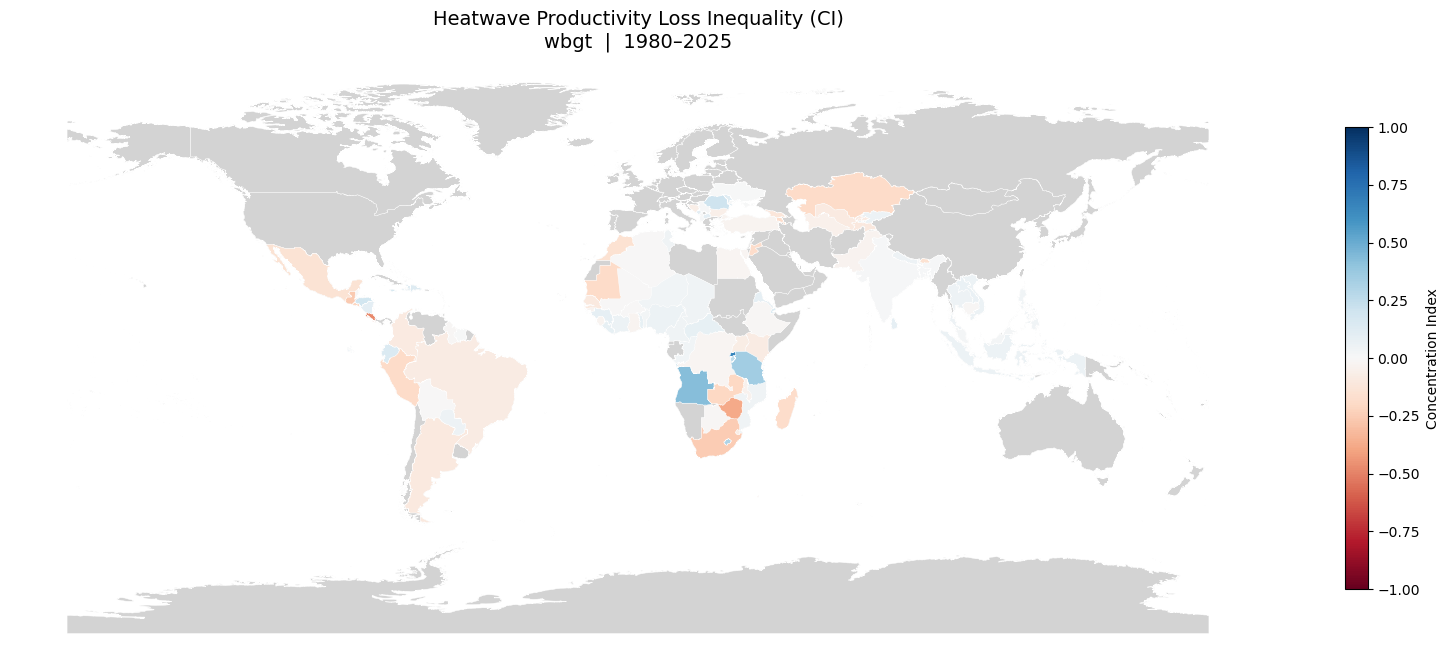

In [36]:
world = gpd.read_file(ROOT / config['data']['boundaries'])

# Identify ISO column
iso_col = next((c for c in ['ADM0_A3', 'ISO_A3', 'iso_a3', 'GID_0', 'shapeGroup']
                if c in world.columns), None)

world_ci = world.merge(ci_df[['iso3', 'CI']], left_on=iso_col, right_on='iso3', how='left')

fig, ax = plt.subplots(figsize=(16, 8))
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_ci.dropna(subset=['CI']).plot(
    ax=ax, column='CI', cmap='RdBu', vmin=-1, vmax=1,
    edgecolor='white', linewidth=0.3, legend=True,
    legend_kwds={'label': 'Concentration Index', 'shrink': 0.6}
)
ax.set_title(
    f'Heatwave Productivity Loss Inequality (CI)\n{DATASET}  |  {EPOCH_START}–{EPOCH_END}',
    fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / f'fig1_ci_map_{DATASET}_{EPOCH_START}_{EPOCH_END}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Concentration curves

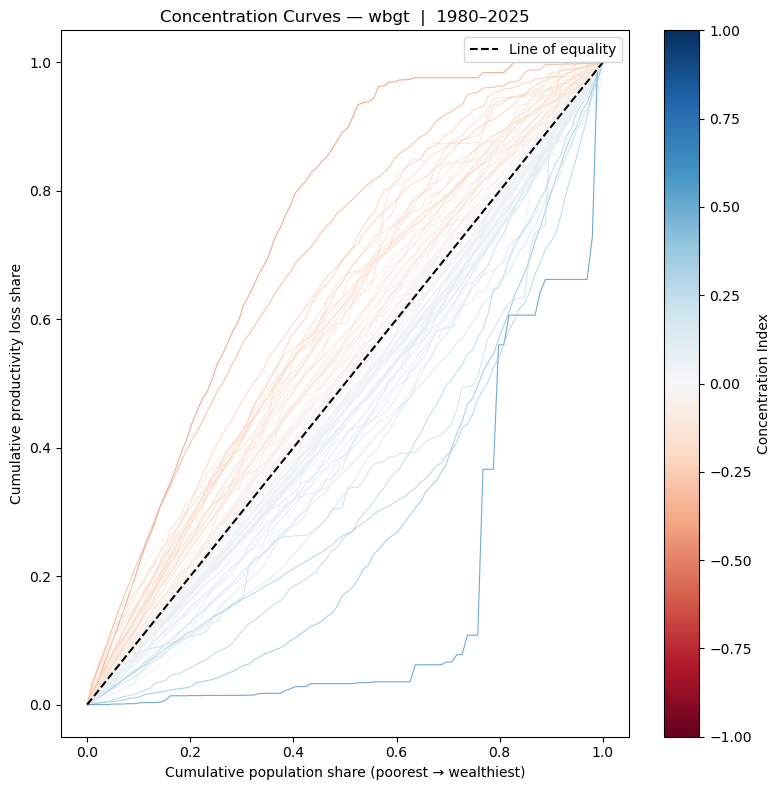

In [37]:
# All countries, coloured by CI value
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)
cmap = plt.cm.RdBu

fig, ax = plt.subplots(figsize=(8, 8))

for iso, grp in curves_df.groupby('iso3'):
    ci_val = ci_df.loc[ci_df['iso3'] == iso, 'CI'].values
    if len(ci_val) == 0:
        continue
    color = cmap(norm(ci_val[0]))
    ax.plot(grp['cum_pop_share'], grp['cum_risk_share'],
            color=color, linewidth=0.8, alpha=0.7)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Line of equality')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Concentration Index')

ax.set_xlabel('Cumulative population share (poorest → wealthiest)')
ax.set_ylabel('Cumulative productivity loss share')
ax.set_title(f'Concentration Curves — {DATASET}  |  {EPOCH_START}–{EPOCH_END}')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / f'fig2_concentration_curves_{DATASET}_{EPOCH_START}_{EPOCH_END}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — CI vs Mean Productivity Loss

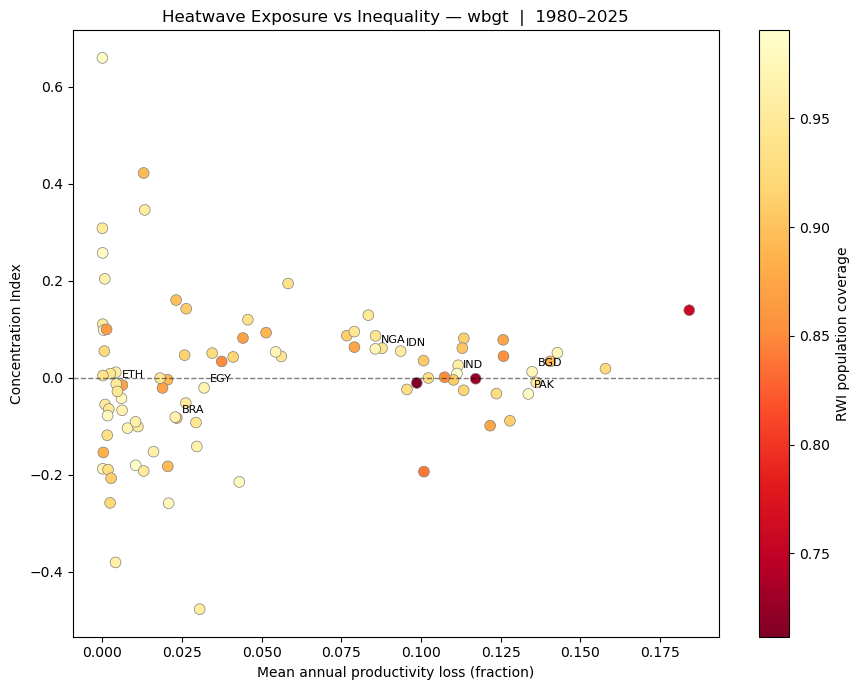

In [38]:
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    ci_df['mean_productivity_loss'],
    ci_df['CI'],
    c=ci_df['rwi_coverage'],
    cmap='YlOrRd_r',
    s=60,
    edgecolors='grey',
    linewidth=0.5,
)

# Label selected countries
highlight = ['IND', 'NGA', 'BRA', 'IDN', 'BGD', 'PAK', 'ETH', 'EGY']
for _, row in ci_df[ci_df['iso3'].isin(highlight)].iterrows():
    ax.annotate(row['iso3'],
                xy=(row['mean_productivity_loss'], row['CI']),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

plt.colorbar(sc, ax=ax, label='RWI population coverage')
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Mean annual productivity loss (fraction)')
ax.set_ylabel('Concentration Index')
ax.set_title(f'Heatwave Exposure vs Inequality — {DATASET}  |  {EPOCH_START}–{EPOCH_END}')
plt.tight_layout()
plt.savefig(RESULTS / f'fig3_exposure_vs_inequality_{DATASET}_{EPOCH_START}_{EPOCH_END}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Change in Productivity Loss (Future − Baseline) and CI of the Delta

Delta raster saved: epoch_delta_wbgt_future_2050_ssp585_vs_wbgt_baseline_1983_2016.tif
Delta range: 0.0000 – 0.1838
Mean delta (valid cells): 0.0296


Delta CI: 100%|████████████████████████████████████████████████████████████████████████| 92/92 [03:58<00:00,  2.60s/it]



Delta CI computed for 92 / 92 countries


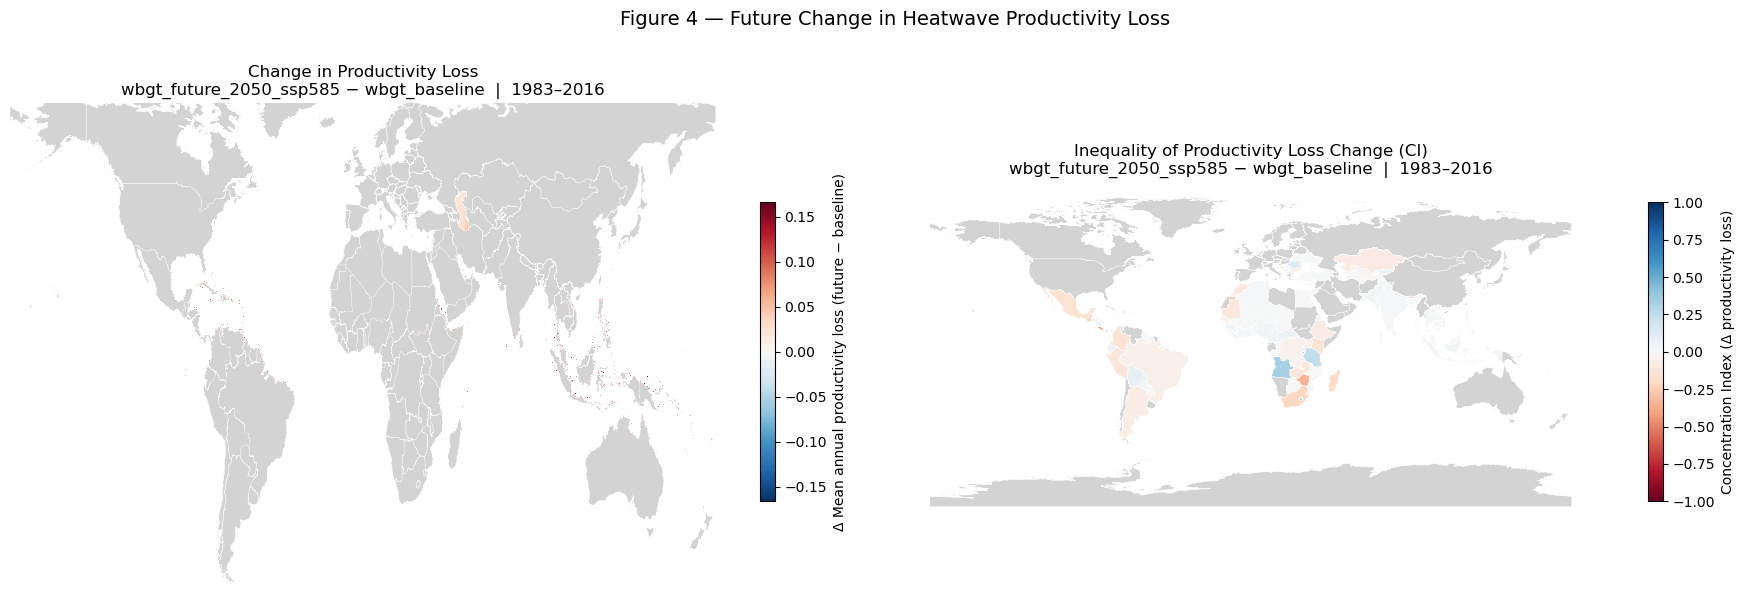


Top 10 countries by CI on delta (most regressive change):
iso3  CI_delta  mean_delta
 BDI  0.362219    0.001312
 AGO  0.335019    0.033895
 LSO  0.317871    0.000156
 TZA  0.244391    0.023761
 RWA  0.166016    0.000008
 ROU  0.132227    0.006458
 JAM  0.113086    0.069156
 MNE  0.097746    0.007864
 BOL  0.076980    0.037113
 KGZ  0.063100    0.005818


In [39]:
import rasterio
import rasterio.warp
from rasterio.warp import reproject, Resampling
from tqdm import tqdm

from scripts.inequality import calculate_CI, prepare_arrays
from scripts.raster_utils import get_country_geometry, align_rasters

# ---------------------------------------------------------------
# Configuration — pick which two datasets to compare
# ---------------------------------------------------------------
BASELINE_DATASET = 'wbgt_baseline'
FUTURE_DATASET   = 'wbgt_future_2050_ssp585'

# Shared epoch (both CHC-CMIP6 datasets span 1983–2016)
COMPARE_START = config['wbgt_future']['start_year']   # 1983
COMPARE_END   = config['wbgt_future']['end_year']     # 2016
# ---------------------------------------------------------------

baseline_path = DATA / 'processed' / f'epoch_mean_{BASELINE_DATASET}_{COMPARE_START}_{COMPARE_END}.tif'
future_path   = DATA / 'processed' / f'epoch_mean_{FUTURE_DATASET}_{COMPARE_START}_{COMPARE_END}.tif'

for p in (baseline_path, future_path):
    if not p.exists():
        raise FileNotFoundError(
            f'{p.name} not found — run notebook 03 with DATASET={p.stem.split("_mean_")[1].rsplit("_",2)[0]!r} first.'
        )

# --- Load baseline and align future to the same grid ---
with rasterio.open(baseline_path) as base_src:
    base_arr  = base_src.read(1).astype(np.float32)
    base_meta = base_src.meta.copy()
    base_transform = base_src.transform
    base_crs       = base_src.crs
    base_shape     = (base_src.height, base_src.width)

with rasterio.open(future_path) as fut_src:
    future_aligned = np.empty(base_shape, dtype=np.float32)
    reproject(
        source=rasterio.band(fut_src, 1),
        destination=future_aligned,
        src_transform=fut_src.transform,
        src_crs=fut_src.crs,
        dst_transform=base_transform,
        dst_crs=base_crs,
        resampling=Resampling.bilinear,
    )

# Delta: future − baseline (positive = more loss in future)
delta = future_aligned - base_arr
delta[np.isnan(base_arr) | np.isnan(future_aligned)] = np.nan

# --- Save delta raster ---
delta_path = DATA / 'processed' / f'epoch_delta_{FUTURE_DATASET}_vs_{BASELINE_DATASET}_{COMPARE_START}_{COMPARE_END}.tif'
delta_meta = base_meta.copy()
delta_meta.update(dtype='float32', nodata=np.nan)
with rasterio.open(delta_path, 'w', **delta_meta) as dst:
    dst.write(delta, 1)
print(f'Delta raster saved: {delta_path.name}')
print(f'Delta range: {np.nanmin(delta):.4f} – {np.nanmax(delta):.4f}')
print(f'Mean delta (valid cells): {np.nanmean(delta):.4f}')

# ---------------------------------------------------------------
# Panel A — pixel-level delta map
# ---------------------------------------------------------------
abs_max = np.nanquantile(np.abs(delta), 0.99)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
im = ax.imshow(
    delta,
    cmap='RdBu_r',
    vmin=-abs_max, vmax=abs_max,
    extent=[base_transform.c,
            base_transform.c + base_transform.a * base_shape[1],
            base_transform.f + base_transform.e * base_shape[0],
            base_transform.f],
    aspect='auto', interpolation='nearest',
)
plt.colorbar(im, ax=ax, label='Δ Mean annual productivity loss (future − baseline)',
             shrink=0.6)
ax.set_title(
    f'Change in Productivity Loss\n{FUTURE_DATASET} − {BASELINE_DATASET}  |  {COMPARE_START}–{COMPARE_END}',
    fontsize=12)
ax.axis('off')

# ---------------------------------------------------------------
# Per-country CI on the delta
# ---------------------------------------------------------------
BOUNDARIES_PATH = str(ROOT / config['data']['boundaries'])
POP_PATH        = str(ROOT / config['data']['population'])
RWI_PATH        = str(ROOT / config['data']['rwi'])
ISO_CODES       = config['iso_codes']

delta_ci_results = []

for iso in tqdm(ISO_CODES, desc='Delta CI'):
    try:
        geom = get_country_geometry(BOUNDARIES_PATH, iso)
        pop, rwi, risk = align_rasters(POP_PATH, RWI_PATH, str(delta_path), geom)
        arrays = prepare_arrays(pop, rwi, risk)
        if arrays is None:
            continue
        pop_f, rwi_f, risk_f = arrays
        ci = calculate_CI(pop_f, rwi_f, risk_f)
        mean_delta = float(np.average(risk_f, weights=pop_f))
        delta_ci_results.append({'iso3': iso, 'CI_delta': ci, 'mean_delta': mean_delta})
    except Exception as e:
        print(f'  {iso}: {e}')

delta_ci_df = pd.DataFrame(delta_ci_results)
print(f'\nDelta CI computed for {len(delta_ci_df)} / {len(ISO_CODES)} countries')

# Save
delta_ci_out = RESULTS / f'delta_ci_{FUTURE_DATASET}_vs_{BASELINE_DATASET}_{COMPARE_START}_{COMPARE_END}.csv'
delta_ci_df.to_csv(delta_ci_out, index=False)

# ---------------------------------------------------------------
# Panel B — choropleth of CI on delta
# ---------------------------------------------------------------
world_delta = world.merge(delta_ci_df[['iso3', 'CI_delta']], left_on=iso_col, right_on='iso3', how='left')

ax2 = axes[1]
world.plot(ax=ax2, color='lightgrey', edgecolor='white', linewidth=0.3)
world_delta.dropna(subset=['CI_delta']).plot(
    ax=ax2, column='CI_delta', cmap='RdBu', vmin=-1, vmax=1,
    edgecolor='white', linewidth=0.3, legend=True,
    legend_kwds={'label': 'Concentration Index (Δ productivity loss)', 'shrink': 0.6}
)
ax2.set_title(
    f'Inequality of Productivity Loss Change (CI)\n{FUTURE_DATASET} − {BASELINE_DATASET}  |  {COMPARE_START}–{COMPARE_END}',
    fontsize=12)
ax2.axis('off')

plt.suptitle('Figure 4 — Future Change in Heatwave Productivity Loss', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(
    RESULTS / f'fig4_delta_{FUTURE_DATASET}_vs_{BASELINE_DATASET}_{COMPARE_START}_{COMPARE_END}.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print(f'\nTop 10 countries by CI on delta (most regressive change):')
print(delta_ci_df.sort_values('CI_delta', ascending=False).head(10).to_string(index=False))
